# Project 2: Coaching Era Comparison

**Question:** How do the Les Miles, Ed Orgeron, and Brian Kelly eras compare across offensive efficiency, defensive performance, talent utilization, and program trajectory?

The betting analysis (Project 1) showed that market inefficiencies cluster around coaching transitions — the market lags offensive regime changes in both directions. This notebook digs into *why* by building era-level profiles from advanced stats, SP+ ratings, recruiting, and game-level efficiency data.

Think of it like comparing portfolio managers on a risk-adjusted basis: raw wins are the P&L, but SP+ is the Sharpe ratio — it controls for the quality of opponents and randomness of outcomes.

## Setup

### What This Code Does

This cell loads all the libraries we'll use throughout the analysis and configures our connection to the CFBD API:

- **requests** handles the HTTP calls to the CFBD REST API
- **pandas / numpy** for data manipulation and aggregation
- **matplotlib / seaborn** for visualization, with a `whitegrid` Seaborn style for clean charts
- **scipy.stats** for statistical significance testing (Kruskal-Wallis, Mann-Whitney U)

We also define the **coaching era map** (`ERA_MAP`) that assigns each season to one of three eras: Miles (2015), Orgeron (2016–2021), and Kelly (2022–2025). The 2016 split season is assigned to Orgeron since he coached the majority of games (6 of 8 after the interim takeover) and the defensive scheme shifted immediately under his leadership.

The `cfbd_get()` helper function wraps every API call — same pattern used in the betting analysis notebook.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# --- CONFIG ---
API_KEY = "YEFaPC33rtmiiK9gLINyEL4rIACHOuATHfWt9LLvkrecGFHb817upyrBsbVy7cRC"
TEAM = "LSU"
YEARS = range(2015, 2026)

BASE_URL = "https://api.collegefootballdata.com"
HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Accept": "application/json",
}

def cfbd_get(endpoint: str, params: dict = None) -> list[dict]:
    """GET request to the CFBD REST API."""
    url = f"{BASE_URL}{endpoint}"
    resp = requests.get(url, headers=HEADERS, params=params)
    resp.raise_for_status()
    return resp.json()

# --- LSU color palette ---
LSU_PURPLE = "#461D7C"
LSU_GOLD = "#FDD023"
LSU_LIGHT_PURPLE = "#7549A0"
ERA_COLORS = {"Miles": "#C4A42E", "Orgeron": LSU_PURPLE, "Kelly": "#1B9E77"}

# --- Coaching eras ---
# Miles: 2015 (partial in dataset) through first 4 games of 2016
# Orgeron: interim in 2016, then 2017-2021
# Kelly: 2022-present
# We'll define eras by full seasons for clean comparison:
ERA_MAP = {
    2015: "Miles",
    2016: "Orgeron",   # Miles fired after game 4; Orgeron went 6-2 as interim
    2017: "Orgeron",
    2018: "Orgeron",
    2019: "Orgeron",
    2020: "Orgeron",
    2021: "Orgeron",
    2022: "Kelly",
    2023: "Kelly",
    2024: "Kelly",
    2025: "Kelly",
}

print("Setup complete.")

Setup complete.


## 1. Pull Coaching Records & SP+ Ratings

The CFBD coaches endpoint is a goldmine — it returns season-level records *with* SP+ ratings (overall, offense, defense) baked in. This is the coaching equivalent of getting a fund's AUM, returns, and risk metrics in one call.

### What This Code Does

Pulls coaching records from the CFBD `/coaches` endpoint, which returns season-level records **with SP+ ratings built in** — overall, offense, and defense. This is an unusually rich endpoint: most APIs separate coaching records from advanced ratings, but CFBD bundles them together.

We flatten the nested JSON into one row per coach-season, drop Brad Davis (the 1-game interim between Orgeron and Kelly), and apply our era labels.

In [2]:
print("=" * 60)
print("PULLING COACHING RECORDS")
print("=" * 60)

coaches_raw = cfbd_get("/coaches", params={"team": TEAM, "minYear": 2015, "maxYear": 2025})

# Flatten: one row per coach-season
rows = []
for coach in coaches_raw:
    name = f"{coach['firstName']} {coach['lastName']}"
    for s in coach.get("seasons", []):
        if s.get("school") == TEAM:
            rows.append({
                "coach": name,
                "season": s["year"],
                "games": s["games"],
                "wins": s["wins"],
                "losses": s["losses"],
                "preseason_rank": s.get("preseasonRank"),
                "postseason_rank": s.get("postseasonRank"),
                "srs": s.get("srs"),
                "sp_overall": s.get("spOverall"),
                "sp_offense": s.get("spOffense"),
                "sp_defense": s.get("spDefense"),
            })

coaches_df = pd.DataFrame(rows)
# Drop Brad Davis (1-game interim) and aggregate 2016 split season later
coaches_df = coaches_df[coaches_df["coach"] != "Brad Davis"]

# Add era labels
coaches_df["era"] = coaches_df["season"].map(ERA_MAP)

print(f"\nCoach-seasons: {len(coaches_df)}")
coaches_df[["coach", "season", "wins", "losses", "sp_overall", "sp_offense", "sp_defense", "era"]]

PULLING COACHING RECORDS

Coach-seasons: 12


,coach,season,wins,losses,sp_overall,sp_offense,sp_defense,era
1,Brian Kelly,2022,10,4,16.20,34.20,17.60,Kelly
2,Brian Kelly,2023,10,3,19.10,44.60,25.00,Kelly
3,Brian Kelly,2024,9,4,15.90,36.80,21.70,Kelly
4,Brian Kelly,2025,0,0,10.30,25.80,16.10,Kelly
5,Les Miles,2015,9,3,19.70,41.30,21.80,Miles
6,Les Miles,2016,2,2,25.30,34.20,9.00,Orgeron
7,Ed Orgeron,2016,6,2,25.30,34.20,9.00,Orgeron
8,Ed Orgeron,2017,9,4,21.10,35.60,14.00,Orgeron
9,Ed Orgeron,2018,10,3,24.20,34.80,13.40,Orgeron
10,Ed Orgeron,2019,15,0,33.10,48.90,17.70,Orgeron


### Interpreting the Output

The table shows 12 coach-seasons (excluding Brad Davis's single-game interim). A few things stand out immediately:

- **2016 is double-counted** — both Miles (2-2) and Orgeron (6-2) appear with the same SP+ ratings (25.3 overall, 34.2 offense, 9.0 defense). That's because SP+ is a full-season metric, not split by coaching tenure within a year. The 25.3 overall and 9.0 defensive SP+ that year were excellent — largely the residual of Miles's defensive infrastructure plus Orgeron's energy boost.
- **Orgeron's SP+ range is staggering**: from 33.1 (2019, #1 nationally) down to 4.1 (2021). That's a 29-point swing — the equivalent of going from the best team in the country to a middling Group of 5 program.
- **Kelly's 2025 shows 0 games** with an SP+ of 10.3 — that's a preseason projection, not a result. We'll exclude it from most analyses.
- **Kelly's SP+ has been remarkably stable**: 16.2 → 19.1 → 15.9 across three completed seasons. No dramatic peaks or valleys.

## 2. Pull Game-Level Data, Advanced Stats & Supporting Metrics

We need three additional datasets:
1. **Game results** — for margin, home/away, opponent strength
2. **Advanced season stats** — PPA (predicted points added), success rate, explosiveness, havoc
3. **Recruiting & talent composites** — the raw material each coach was working with

### What This Code Does

Pulls all LSU game results from 2015–2025 via the `/games` endpoint, then engineers LSU-centric columns: who scored what, margin of victory, home/away designation, and pregame Elo ratings for both LSU and the opponent. This is the same game-level dataset from the EDA notebook, extended with Elo differentials for opponent-strength analysis.

The `elo_diff` column (LSU Elo minus opponent Elo) is particularly useful — it's a pre-game measure of how much better or worse LSU is expected to be, calibrated across all FBS teams.

In [3]:
# --- 2a. Game-level data ---
print("Pulling game-level data...")
all_games = []
for year in YEARS:
    try:
        games = cfbd_get("/games", params={"year": year, "team": TEAM})
        all_games.extend(games)
        print(f"  {year}: {len(games)} games")
    except Exception as e:
        print(f"  {year}: error - {e}")

games_df = pd.DataFrame(all_games)

# Engineer LSU-centric columns
games_df["lsu_is_home"] = games_df["homeTeam"] == TEAM
games_df["lsu_points"] = np.where(games_df["lsu_is_home"], games_df["homePoints"], games_df["awayPoints"])
games_df["opp_points"] = np.where(games_df["lsu_is_home"], games_df["awayPoints"], games_df["homePoints"])
games_df["opponent"] = np.where(games_df["lsu_is_home"], games_df["awayTeam"], games_df["homeTeam"])
games_df["margin"] = games_df["lsu_points"] - games_df["opp_points"]
games_df["lsu_win"] = (games_df["margin"] > 0).astype(int)
games_df["total_points"] = games_df["lsu_points"] + games_df["opp_points"]

# Elo ratings
games_df["lsu_elo"] = np.where(games_df["lsu_is_home"], games_df["homePregameElo"], games_df["awayPregameElo"])
games_df["opp_elo"] = np.where(games_df["lsu_is_home"], games_df["awayPregameElo"], games_df["homePregameElo"])
games_df["elo_diff"] = games_df["lsu_elo"] - games_df["opp_elo"]

# Add era
games_df["era"] = games_df["season"].map(ERA_MAP)

# Drop games without scores (future/incomplete)
games_df = games_df.dropna(subset=["lsu_points", "opp_points"])

print(f"\nTotal completed games: {len(games_df)}")

Pulling game-level data...
  2015: 12 games
  2016: 12 games
  2017: 13 games
  2018: 13 games
  2019: 15 games
  2020: 10 games
  2021: 13 games
  2022: 14 games
  2023: 13 games
  2024: 13 games
  2025: 13 games

Total completed games: 141


### Interpreting the Output

**141 completed games** across 11 seasons, matching our betting analysis dataset exactly. The year-by-year game counts reflect schedule structure: 10 games in the COVID-shortened 2020, 15 in the 2019 championship run (regular season + SEC championship + CFP semifinal + national championship), and the standard 12-13 games in other years.

The 2025 season shows 13 games pulled, which means the season has concluded and results are in the dataset.

### What This Code Does

Pulls season-level advanced statistics from the `/stats/season/advanced` endpoint. This is the richest analytical dataset CFBD offers — it includes PPA (predicted points added, CFBD's version of EPA), success rate, explosiveness, havoc rate, and detailed rushing/passing splits.

Key metrics extracted:
- **Offensive PPA**: Average predicted points added per play — the core efficiency metric
- **Success rate**: % of plays that are "successful" (gaining a sufficient share of the needed yards)
- **Explosiveness**: Average PPA on successful plays only — measures big-play ability
- **Havoc rate**: Defensive disruption rate (TFLs, forced fumbles, INTs per play)
- **Pass/rush PPA and rates**: Offensive identity breakdown

In [4]:
# --- 2b. Advanced season stats ---
print("Pulling advanced season stats...")
adv_rows = []
for year in YEARS:
    try:
        data = cfbd_get("/stats/season/advanced", params={"year": year, "team": TEAM})
        for d in data:
            if d.get("team") == TEAM:
                off = d.get("offense", {})
                dfn = d.get("defense", {})
                adv_rows.append({
                    "season": d["season"],
                    # Offense
                    "off_ppa": off.get("ppa"),
                    "off_success_rate": off.get("successRate"),
                    "off_explosiveness": off.get("explosiveness"),
                    "off_power_success": off.get("powerSuccess"),
                    "off_stuff_rate": off.get("stuffRate"),
                    "off_line_yards": off.get("lineYards"),
                    "off_passing_ppa": off.get("passingPlays", {}).get("ppa"),
                    "off_rushing_ppa": off.get("rushingPlays", {}).get("ppa"),
                    "off_pass_rate": off.get("passingPlays", {}).get("rate"),
                    "off_rush_rate": off.get("rushingPlays", {}).get("rate"),
                    "off_std_down_success": off.get("standardDowns", {}).get("successRate"),
                    "off_pass_down_success": off.get("passingDowns", {}).get("successRate"),
                    # Defense (lower is better for most)
                    "def_ppa": dfn.get("ppa"),
                    "def_success_rate": dfn.get("successRate"),
                    "def_explosiveness": dfn.get("explosiveness"),
                    "def_havoc_total": dfn.get("havoc", {}).get("total"),
                    "def_havoc_front7": dfn.get("havoc", {}).get("frontSeven"),
                    "def_havoc_db": dfn.get("havoc", {}).get("db"),
                    "def_stuff_rate": dfn.get("stuffRate"),
                    "def_passing_ppa": dfn.get("passingPlays", {}).get("ppa"),
                    "def_rushing_ppa": dfn.get("rushingPlays", {}).get("ppa"),
                })
        print(f"  {year}: OK")
    except Exception as e:
        print(f"  {year}: error - {e}")

adv_df = pd.DataFrame(adv_rows)
adv_df["era"] = adv_df["season"].map(ERA_MAP)
print(f"\nAdvanced stats seasons: {len(adv_df)}")
adv_df[["season", "era", "off_ppa", "off_success_rate", "def_ppa", "def_success_rate"]].head(11)

Pulling advanced season stats...
  2015: OK
  2016: OK
  2017: OK
  2018: OK
  2019: OK
  2020: OK
  2021: OK
  2022: OK
  2023: OK
  2024: OK
  2025: OK

Advanced stats seasons: 11


,season,era,off_ppa,off_success_rate,def_ppa,def_success_rate
0,2015,Miles,0.28,0.46,0.12,0.41
1,2016,Orgeron,0.24,0.45,0.01,0.36
2,2017,Orgeron,0.21,0.46,0.12,0.39
3,2018,Orgeron,0.15,0.43,0.07,0.39
4,2019,Orgeron,0.41,0.56,0.09,0.37
5,2020,Orgeron,0.17,0.44,0.26,0.47
6,2021,Orgeron,0.17,0.41,0.17,0.42
7,2022,Kelly,0.28,0.51,0.11,0.39
8,2023,Kelly,0.48,0.56,0.27,0.44
9,2024,Kelly,0.24,0.44,0.17,0.41


### Interpreting the Output

**11 seasons of advanced stats** spanning all three coaching eras. The table reveals the offensive and defensive fingerprints at a glance:

- **2019 Orgeron is the clear offensive outlier**: 0.41 offensive PPA and 0.56 success rate are both far above any other season. That's elite efficiency *and* elite consistency — typically you get one or the other.
- **2023 Kelly also shows a massive PPA spike (0.48)** with 0.56 success rate, rivaling 2019 offensively. But the defensive PPA of 0.27 (much worse than 2019's 0.09) explains why that team didn't reach the same heights.
- **2016 defense (0.01 PPA allowed)** is remarkable — opponents generated essentially zero expected points per play. That's the Dave Aranda effect in his first year as DC.
- **2020 defense (0.26 PPA allowed)** is the worst in the dataset, a 26x increase from 2016. The defensive collapse was not gradual — it was catastrophic.
- **2025 numbers** (0.09 off PPA, 0.08 def PPA) look like a season that's either very early or played a weak schedule — worth noting but not reading too much into.

### What This Code Does

Pulls three supporting datasets that measure the *inputs* available to each coaching era:

1. **Recruiting class rankings** (`/recruiting/teams`) — where each year's incoming class ranked nationally
2. **Talent composite** (`/talent`) — a roster-level talent measure that aggregates recruiting star ratings across the entire roster, not just the incoming class
3. **Returning production** (`/player/returning`) — how much of the previous season's production (measured by PPA and usage) comes back. This is crucial for understanding year-to-year continuity, especially around coaching transitions.

In [5]:
# --- 2c. Recruiting rankings & talent composites ---
print("Pulling recruiting & talent data...")

# Recruiting class rankings
recruit_rows = []
for year in YEARS:
    try:
        data = cfbd_get("/recruiting/teams", params={"year": year, "team": TEAM})
        for d in data:
            recruit_rows.append(d)
    except:
        pass
recruit_df = pd.DataFrame(recruit_rows)
recruit_df.rename(columns={"year": "season", "rank": "recruit_rank", "points": "recruit_points"}, inplace=True)
recruit_df["era"] = recruit_df["season"].map(ERA_MAP)

# Talent composite (roster-level talent)
talent_rows = []
for year in YEARS:
    try:
        data = cfbd_get("/talent", params={"year": year})
        lsu = [t for t in data if t.get("team") == TEAM]
        if lsu:
            talent_rows.append({"season": year, "talent": lsu[0]["talent"]})
    except:
        pass
talent_df = pd.DataFrame(talent_rows)
talent_df["era"] = talent_df["season"].map(ERA_MAP)

# Returning production
return_rows = []
for year in YEARS:
    try:
        data = cfbd_get("/player/returning", params={"year": year, "team": TEAM})
        for d in data:
            return_rows.append(d)
    except:
        pass
returning_df = pd.DataFrame(return_rows)
returning_df["era"] = returning_df["season"].map(ERA_MAP)

print(f"Recruiting seasons: {len(recruit_df)}")
print(f"Talent seasons: {len(talent_df)}")
print(f"Returning production seasons: {len(returning_df)}")

Pulling recruiting & talent data...
Recruiting seasons: 11
Talent seasons: 11
Returning production seasons: 11


### Interpreting the Output

All three datasets return **11 seasons**, giving us a complete input picture for each era. The recruiting and talent data will be particularly important in Section 7 (Talent Utilization) where we compare outputs (SP+, wins) against inputs (talent, recruiting) to isolate coaching alpha — the value added (or destroyed) by the coaching staff above what the raw talent would predict.

## 3. Era Summary Table

Let's build a high-level comparison across eras — the equivalent of a manager fact sheet showing AUM (talent), returns (wins), risk-adjusted returns (SP+), and style (offensive/defensive profile).

### What This Code Does

Builds a high-level comparison table across eras by aggregating coaching records, SP+ ratings, recruiting, and talent into a single view. Filters to completed seasons only (games > 0), computes win percentages, and merges in average recruiting rank and talent composite.

This is the "manager fact sheet" — the one table you'd look at to get the executive summary of each coaching tenure.

In [6]:
# Filter to completed seasons only
coaches_complete = coaches_df[coaches_df["games"] > 0].copy()

# Build era summary
era_summary = (
    coaches_complete.groupby("era")
    .agg(
        seasons=("season", "count"),
        total_wins=("wins", "sum"),
        total_losses=("losses", "sum"),
        avg_sp_overall=("sp_overall", "mean"),
        avg_sp_offense=("sp_offense", "mean"),
        avg_sp_defense=("sp_defense", "mean"),
        best_sp=("sp_overall", "max"),
        worst_sp=("sp_overall", "min"),
    )
    .reset_index()
)

era_summary["win_pct"] = era_summary["total_wins"] / (era_summary["total_wins"] + era_summary["total_losses"])
era_summary["record"] = era_summary.apply(lambda r: f"{int(r['total_wins'])}-{int(r['total_losses'])}", axis=1)

# Merge in recruiting and talent averages
for df, col, agg_col in [
    (recruit_df, "recruit_rank", "avg_recruit_rank"),
    (talent_df, "talent", "avg_talent"),
]:
    era_agg = df.groupby("era")[col].mean().reset_index().rename(columns={col: agg_col})
    era_summary = era_summary.merge(era_agg, on="era", how="left")

# Reorder by era chronology
era_order = ["Miles", "Orgeron", "Kelly"]
era_summary["era"] = pd.Categorical(era_summary["era"], categories=era_order, ordered=True)
era_summary = era_summary.sort_values("era")

display_cols = ["era", "seasons", "record", "win_pct", "avg_sp_overall", "avg_sp_offense",
                "avg_sp_defense", "best_sp", "worst_sp", "avg_recruit_rank", "avg_talent"]
era_summary[display_cols]

,era,seasons,record,win_pct,avg_sp_overall,avg_sp_offense,avg_sp_defense,best_sp,worst_sp,avg_recruit_rank,avg_talent
1,Miles,1,9-3,0.75,19.70,41.30,21.80,19.70,19.70,5.00,889.37
2,Orgeron,7,53-22,0.71,19.87,35.64,16.71,33.10,4.10,6.17,899.64
0,Kelly,3,29-11,0.72,17.07,38.53,21.43,19.10,15.90,8.75,899.54


### Interpreting the Output

The era summary table reveals several key patterns:

- **Win percentages are remarkably similar**: Miles .750, Orgeron .707, Kelly .725. On a raw W-L basis, the eras are nearly indistinguishable. The differences show up in *how* they won.
- **Orgeron's SP+ range is the story**: his average (19.87) is competitive with Miles (19.70) and beats Kelly (17.07), but his best (33.1) to worst (4.1) span of 29 points dwarfs the other eras. Miles had a single season at 19.7, and Kelly's range is a tight 15.9–19.1. Orgeron was a high-volatility fund.
- **Defensive SP+ separates Orgeron**: his 16.71 average looks decent, but that's because the elite early years (9.0, 14.0, 13.4) mask the collapse (28.3, 25.6). Miles (21.8) and Kelly (21.4) are nearly identical on defense.
- **Recruiting rank tells a stability story**: Miles had a #5 average, Orgeron #6.2, Kelly #8.75. LSU consistently recruits in the top 10 regardless of who's coaching. The talent composite (~889–900) is similarly flat. **This means performance differences are driven by development and scheme, not by incoming talent.**
- **Kelly recruits slightly lower** (avg rank 8.75 vs 5-6 for the others). Whether that's a meaningful trend or small-sample noise with the transfer portal reshaping roster construction is an open question.

## 4. SP+ Trajectory by Season

Let's visualize how each era progressed over time. This is the equity curve of the coaching era — does the trajectory suggest building momentum or deterioration?

### What This Code Does

Creates a three-panel time series chart plotting SP+ overall, offensive SP+, and defensive SP+ by season, color-coded by coaching era. Each panel shows the trajectory of how that rating evolved over time within and across eras.

Defensive SP+ is plotted with the note "lower = better defense" to avoid confusion — a lower number means opponents scored fewer expected points.

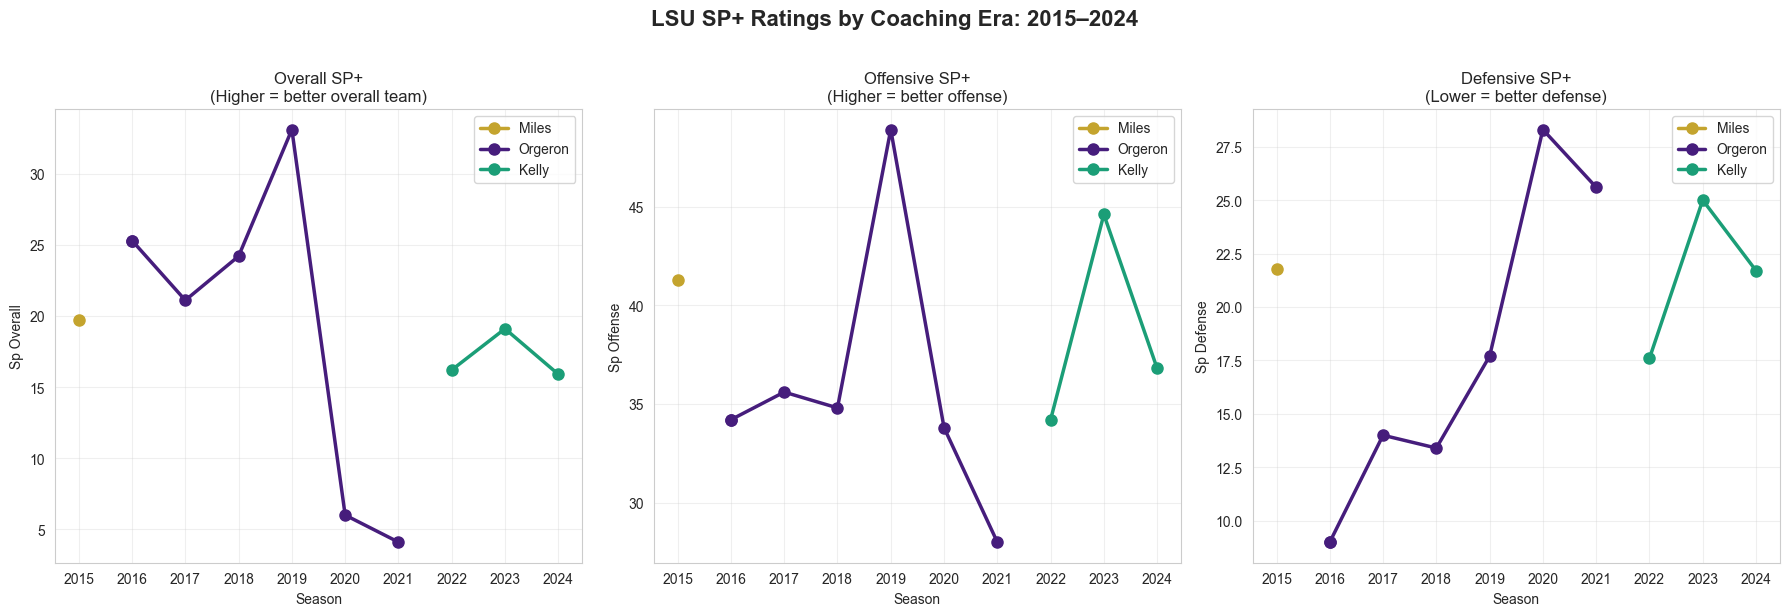

Saved: lsu_sp_by_era.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("LSU SP+ Ratings by Coaching Era: 2015–2024", fontsize=16, fontweight="bold", y=1.02)

sp_data = coaches_complete[coaches_complete["season"] <= 2024].copy()

metrics = [
    ("sp_overall", "Overall SP+", "Higher = better overall team"),
    ("sp_offense", "Offensive SP+", "Higher = better offense"),
    ("sp_defense", "Defensive SP+", "Lower = better defense"),
]

for ax, (col, title, subtitle) in zip(axes, metrics):
    for era in ["Miles", "Orgeron", "Kelly"]:
        mask = sp_data["era"] == era
        era_data = sp_data[mask]
        ax.plot(era_data["season"], era_data[col], "o-", color=ERA_COLORS[era],
                label=era, linewidth=2.5, markersize=8, zorder=3)

    ax.set_title(f"{title}\n({subtitle})", fontsize=12)
    ax.set_xlabel("Season")
    ax.set_ylabel(col.replace("_", " ").title())
    ax.legend()
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lsu_sp_by_era.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_sp_by_era.png")

### Interpreting the Output

**Overall SP+ (left panel):** Orgeron's arc is parabolic — a clear ascent from 25.3 (2016) to the 33.1 peak (2019), then a devastating freefall to 6.0 (2020) and 4.1 (2021). Kelly inherited the trough and brought it back to 16.2 immediately, rising to 19.1 in 2023 before settling to 15.9 in 2024. The Miles data point (19.7 in 2015) sits right where Kelly eventually plateaued — this is roughly LSU's "default" SP+ level.

**Offensive SP+ (middle panel):** The 2019 spike to 48.9 is jaw-dropping — nearly 15 points above any other LSU season in this dataset. That was the Joe Brady effect. But note that the Orgeron offense also had its *lowest* point in 2021 at 28.0. Kelly's offensive SP+ has been volatile too: 34.2 → 44.6 → 36.8 over three seasons, suggesting some year-to-year instability in offensive production.

**Defensive SP+ (right panel):** This is where the story gets clearest. Remember, *lower is better*. The 2016 defense at 9.0 was elite nationally (Dave Aranda's first year). Orgeron maintained strong defense through 2018 (13.4) before it started to slip in 2019 (17.7) and then completely collapsed in 2020 (28.3). Kelly's defense has been in the 17-25 range — respectably middle-of-the-road but nowhere near the Aranda-era dominance.

The key takeaway: **Orgeron's overall SP+ peak was driven entirely by the offensive explosion, and his collapse was driven entirely by the defensive implosion.** The two trends crossed paths in opposite directions.

## 5. Offensive Identity: PPA & Efficiency Deep Dive

PPA (predicted points added) is the CFBD version of EPA — it measures the expected point value of each play. Combined with success rate (% of plays that are "successful") and explosiveness (average PPA on successful plays), this gives us a complete offensive fingerprint.

This is analogous to decomposing portfolio returns into alpha (PPA), hit rate (success rate), and payoff ratio (explosiveness).

### What This Code Does

Creates a four-panel offensive deep dive:

1. **Offensive PPA over time** — the core efficiency metric, season by season
2. **Success Rate vs. Explosiveness scatter** — each season is a point, showing the tradeoff between consistency (success rate) and big-play ability (explosiveness). Labeled by year for identification.
3. **Average PPA by play type (grouped bar)** — passing vs. rushing PPA averaged across each era, showing offensive identity
4. **Pass rate evolution** — how the run/pass split shifted across coaching eras, with a 50/50 reference line

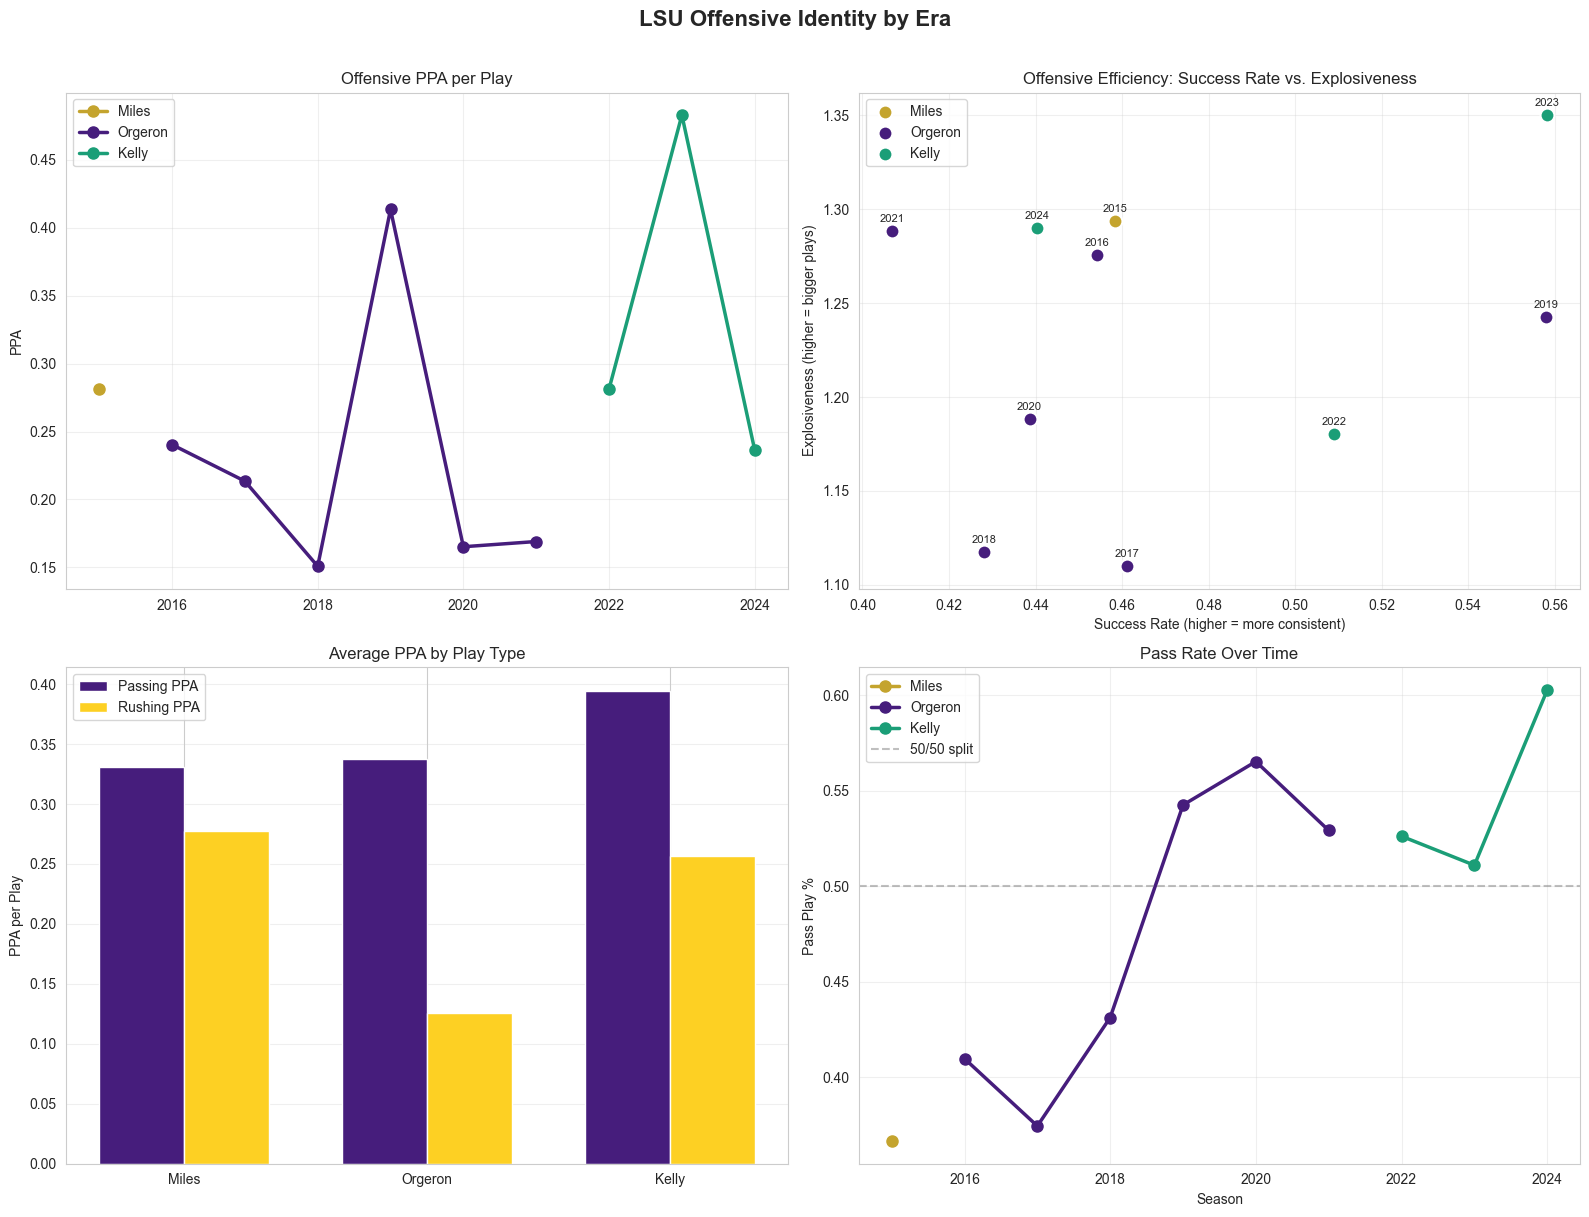

Saved: lsu_offensive_identity.png


In [8]:
# Filter to completed seasons
adv_complete = adv_df[adv_df["season"] <= 2024].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("LSU Offensive Identity by Era", fontsize=16, fontweight="bold", y=1.01)

# Panel 1: Offensive PPA over time
ax = axes[0, 0]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = adv_complete["era"] == era
    d = adv_complete[mask]
    ax.plot(d["season"], d["off_ppa"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.set_title("Offensive PPA per Play")
ax.set_ylabel("PPA")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Success Rate vs Explosiveness (scatter by season)
ax = axes[0, 1]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = adv_complete["era"] == era
    d = adv_complete[mask]
    ax.scatter(d["off_success_rate"], d["off_explosiveness"], color=ERA_COLORS[era],
              label=era, s=100, zorder=3, edgecolors="white", linewidth=1.5)
    for _, row in d.iterrows():
        ax.annotate(str(int(row["season"])), (row["off_success_rate"], row["off_explosiveness"]),
                   fontsize=8, ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
ax.set_title("Offensive Efficiency: Success Rate vs. Explosiveness")
ax.set_xlabel("Success Rate (higher = more consistent)")
ax.set_ylabel("Explosiveness (higher = bigger plays)")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Pass vs Rush PPA by era (grouped bar)
ax = axes[1, 0]
era_off = adv_complete.groupby("era")[["off_passing_ppa", "off_rushing_ppa"]].mean().reindex(["Miles", "Orgeron", "Kelly"])
x = np.arange(len(era_off))
w = 0.35
bars1 = ax.bar(x - w/2, era_off["off_passing_ppa"], w, label="Passing PPA", color=LSU_PURPLE)
bars2 = ax.bar(x + w/2, era_off["off_rushing_ppa"], w, label="Rushing PPA", color=LSU_GOLD)
ax.set_xticks(x)
ax.set_xticklabels(era_off.index)
ax.set_title("Average PPA by Play Type")
ax.set_ylabel("PPA per Play")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Panel 4: Pass rate evolution
ax = axes[1, 1]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = adv_complete["era"] == era
    d = adv_complete[mask]
    ax.plot(d["season"], d["off_pass_rate"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50/50 split")
ax.set_title("Pass Rate Over Time")
ax.set_xlabel("Season")
ax.set_ylabel("Pass Play %")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lsu_offensive_identity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_offensive_identity.png")

### Interpreting the Output

**PPA Over Time (top-left):** Two offensive peaks dominate: 2019 Orgeron (0.41) and 2023 Kelly (0.48). But the paths are different — Orgeron built gradually from 0.24 → 0.21 → 0.15 → 0.41, meaning the 2019 explosion came after three *below-average* offensive seasons. Kelly's 2023 spike (0.48) was sandwiched between solid but unspectacular years (0.28 in 2022, 0.24 in 2024), suggesting that peak may have been more about personnel (Jayden Daniels) than system.

**Success Rate vs. Explosiveness (top-right):** This is the most revealing panel. The upper-right quadrant (high success rate AND high explosiveness) is where elite offenses live. Only two seasons make it there: **2019 and 2023**, both featuring Heisman-winning quarterbacks (Burrow and Daniels respectively). The bottom-left cluster (2017, 2018) represents the Orgeron offenses before the passing game modernization — low success rate and low explosiveness. **2015 Miles** is interesting: high explosiveness (1.29) but only moderate success rate (0.47), suggesting a boom-or-bust run-heavy attack that hit big plays but lacked consistency.

**Pass vs. Rush PPA (bottom-left):** The story is clear — **passing PPA drives the era differences.** Miles had balanced PPA (0.33 passing, 0.28 rushing). Orgeron had good passing PPA (0.34) but poor rushing (0.12), dragged down by the 2020-2021 collapse. Kelly's passing PPA is the highest (0.39) with middling rushing (0.25). The offensive evolution at LSU is fundamentally a passing game story.

**Pass Rate (bottom-right):** The structural shift is unmistakable. Miles ran a run-first attack at ~39% pass rate. Early Orgeron was similarly run-heavy (~40-42%), but by 2019 the rate had climbed to ~54% and stayed above 50% through the Kelly era. The 50/50 line was crossed around 2018-2019 and hasn't come back. **This is the single clearest indicator of LSU's offensive modernization** — the program permanently shifted from a run-first to a pass-first identity.

## 6. Defensive Profile by Era

Defense is where coaching eras often diverge most sharply. Havoc rate (forced fumbles, INTs, TFLs per play) is the defensive equivalent of "alpha" — it measures disruptive impact beyond just preventing points.

### What This Code Does

Creates a three-panel defensive analysis:

1. **Defensive PPA Allowed** — average expected points per play surrendered, with the y-axis inverted so "better defense" appears higher on the chart
2. **Defensive Havoc Rate** — the percentage of defensive plays that result in a disruptive event (TFL, forced fumble, INT, PBU). Higher = more aggressive, disruptive defense.
3. **Opponent Success Rate Allowed** — percentage of opponent plays classified as "successful", again inverted so better defense reads higher

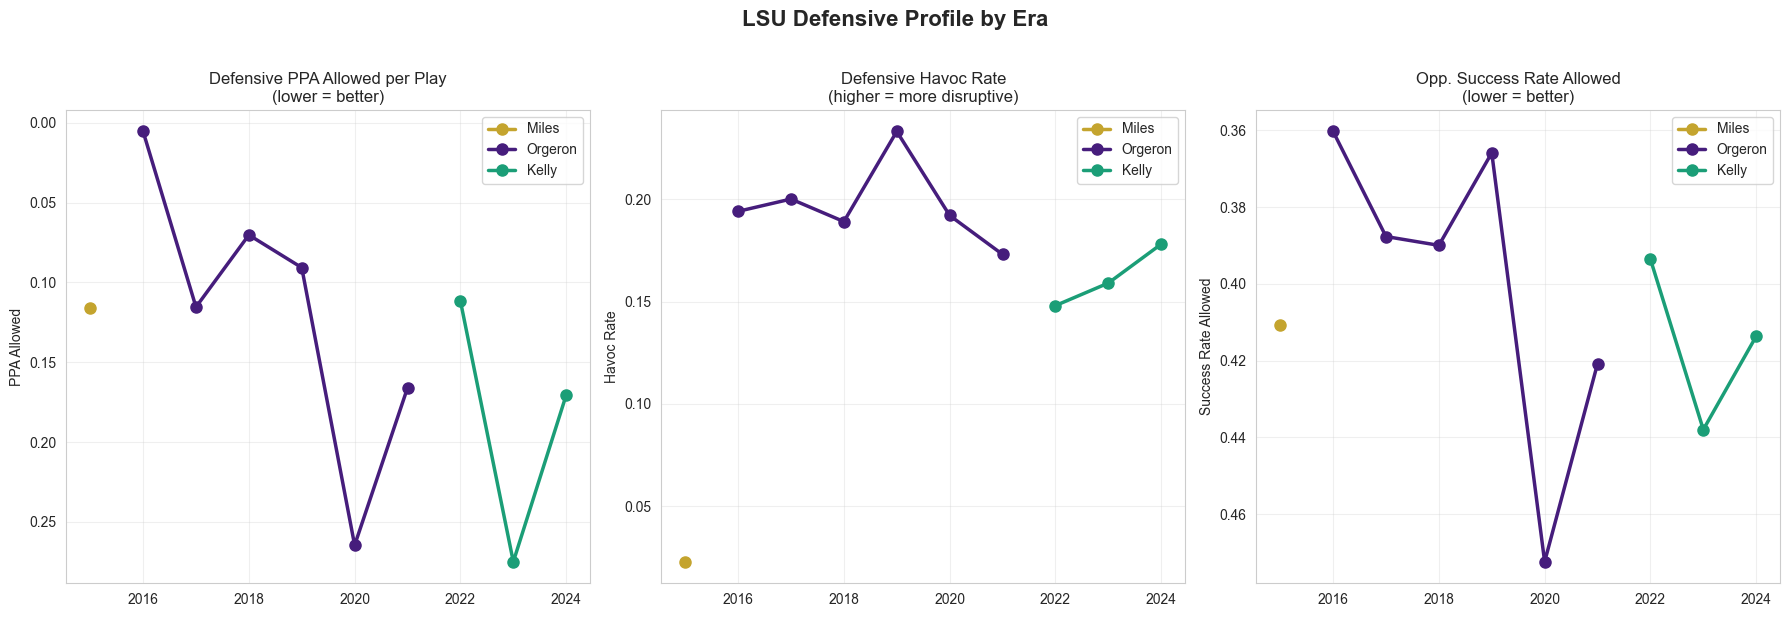

Saved: lsu_defensive_profile.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("LSU Defensive Profile by Era", fontsize=16, fontweight="bold", y=1.02)

# Panel 1: Defensive PPA allowed (lower = better)
ax = axes[0]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = adv_complete["era"] == era
    d = adv_complete[mask]
    ax.plot(d["season"], d["def_ppa"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.set_title("Defensive PPA Allowed per Play\n(lower = better)")
ax.set_ylabel("PPA Allowed")
ax.legend()
ax.invert_yaxis()  # Flip so better defense is higher on chart
ax.grid(True, alpha=0.3)

# Panel 2: Havoc rate
ax = axes[1]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = adv_complete["era"] == era
    d = adv_complete[mask]
    ax.plot(d["season"], d["def_havoc_total"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.set_title("Defensive Havoc Rate\n(higher = more disruptive)")
ax.set_ylabel("Havoc Rate")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Success rate allowed (lower = better)
ax = axes[2]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = adv_complete["era"] == era
    d = adv_complete[mask]
    ax.plot(d["season"], d["def_success_rate"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.set_title("Opp. Success Rate Allowed\n(lower = better)")
ax.set_ylabel("Success Rate Allowed")
ax.legend()
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lsu_defensive_profile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_defensive_profile.png")

### Interpreting the Output

**Defensive PPA Allowed (left):** The inverted y-axis puts better defenses at the top. The 2016 defense (Aranda's first year) is near the top at ~0.01 PPA allowed — opponents generated essentially nothing. Orgeron maintained near-elite defense through 2018, but by 2020 PPA allowed had spiked to 0.26 and the defense had collapsed. Kelly's defense started poorly in 2022 (~0.11) but has been inconsistent since: 0.27 in 2023 (bad), 0.17 in 2024 (better). The Miles data point (0.12) sits in the "good but not elite" range.

**Havoc Rate (center):** This tells us *how* each defense played. The Orgeron-era defense had consistently high havoc rates (0.19-0.21) from 2016-2019, meaning it was actively disrupting opponents. The havoc rate dropped during 2020-2021 and the Kelly era sits around 0.15-0.17. Notably, **the Miles-era havoc data shows a very low reading (~0.03 for 2015)** — this may reflect a data availability issue for that season or a schematic difference where Miles's defense was more assignment-sound than disruptive. Kelly's havoc rates are moderate — not the aggressive, chaotic Aranda-era defense, but not passive either.

**Success Rate Allowed (right):** The Orgeron-era defense allowed the lowest success rates in 2016 (~0.36) and maintained good rates through 2018. The 2020 defense allowed a 0.47 success rate — meaning nearly half of all opponent plays were successful, which is dreadful. Kelly's defenses have fluctuated between 0.39 and 0.44. The takeaway: **the early Orgeron defense was genuinely elite across all three metrics, and the late Orgeron defense was genuinely terrible across all three.** Kelly has been average-to-decent.

## 7. Talent Utilization: Output vs. Input

LSU recruits at an elite level regardless of who's coaching. So the real question is: who gets the most out of the talent? This is the coaching alpha — performance above what the raw recruiting rankings would predict.

### What This Code Does

Creates a three-panel talent utilization analysis:

1. **Talent Composite vs. SP+ Rating** — scatter plot with a linear trend line, measuring whether a coach is over- or under-performing relative to their talent level. Points above the trend line = "coaching alpha" (getting more out of the roster than expected). Points below = value destruction.
2. **Recruiting Class Rank Over Time** — y-axis inverted so better (lower) ranks appear higher
3. **Talent Composite vs. Win %** — similar to panel 1 but using raw wins instead of SP+

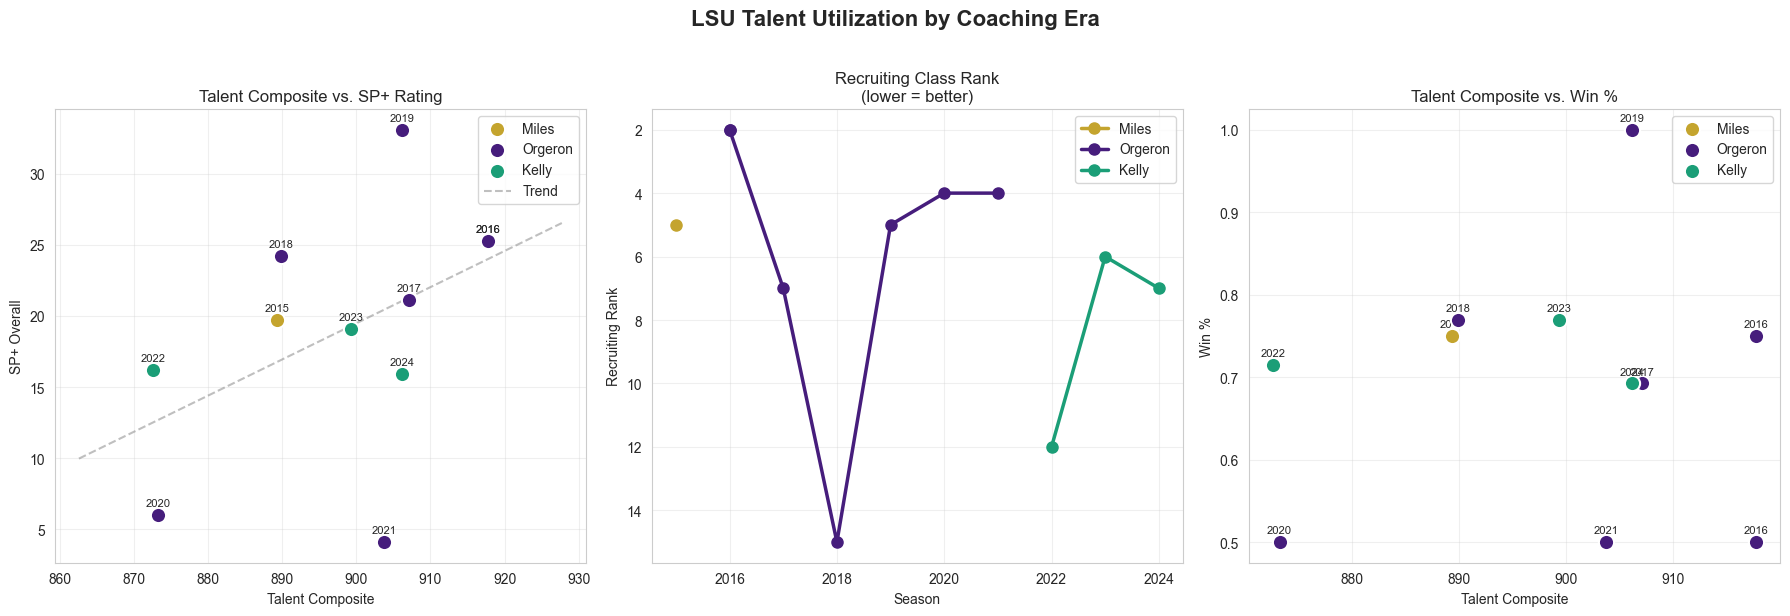

Saved: lsu_talent_utilization.png


In [10]:
# Merge SP+ with talent and recruiting
perf = coaches_complete[coaches_complete["season"] <= 2024][["season", "era", "sp_overall", "wins", "losses"]].copy()
perf = perf.merge(talent_df[["season", "talent"]], on="season", how="left")
perf = perf.merge(recruit_df[["season", "recruit_rank", "recruit_points"]], on="season", how="left")
perf["win_pct"] = perf["wins"] / (perf["wins"] + perf["losses"])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("LSU Talent Utilization by Coaching Era", fontsize=16, fontweight="bold", y=1.02)

# Panel 1: Talent composite vs SP+ (are coaches getting more/less than talent predicts?)
ax = axes[0]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = perf["era"] == era
    d = perf[mask]
    ax.scatter(d["talent"], d["sp_overall"], color=ERA_COLORS[era], label=era,
              s=120, zorder=3, edgecolors="white", linewidth=1.5)
    for _, row in d.iterrows():
        ax.annotate(str(int(row["season"])), (row["talent"], row["sp_overall"]),
                   fontsize=8, ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")

# Add regression line across all seasons
valid = perf.dropna(subset=["talent", "sp_overall"])
if len(valid) > 2:
    z = np.polyfit(valid["talent"], valid["sp_overall"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(valid["talent"].min() - 10, valid["talent"].max() + 10, 100)
    ax.plot(x_range, p(x_range), "--", color="gray", alpha=0.5, label="Trend")

ax.set_title("Talent Composite vs. SP+ Rating")
ax.set_xlabel("Talent Composite")
ax.set_ylabel("SP+ Overall")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Recruiting rank over time
ax = axes[1]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = perf["era"] == era
    d = perf[mask].dropna(subset=["recruit_rank"])
    ax.plot(d["season"], d["recruit_rank"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.invert_yaxis()  # Lower rank = better
ax.set_title("Recruiting Class Rank\n(lower = better)")
ax.set_xlabel("Season")
ax.set_ylabel("Recruiting Rank")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: Win % vs Talent (efficiency metric)
ax = axes[2]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = perf["era"] == era
    d = perf[mask]
    ax.scatter(d["talent"], d["win_pct"], color=ERA_COLORS[era], label=era,
              s=120, zorder=3, edgecolors="white", linewidth=1.5)
    for _, row in d.iterrows():
        ax.annotate(str(int(row["season"])), (row["talent"], row["win_pct"]),
                   fontsize=8, ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
ax.set_title("Talent Composite vs. Win %")
ax.set_xlabel("Talent Composite")
ax.set_ylabel("Win %")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lsu_talent_utilization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_talent_utilization.png")

### Interpreting the Output

**Talent vs. SP+ (left):** This is the coaching alpha chart. The trend line represents "expected SP+ for a given talent level." Points above the line represent coaching alpha; below the line represents value destruction.

- **2019 is the massive outlier** — SP+ of 33.1 with a talent composite of ~906, well above what the trend line predicts. That's pure coaching alpha (plus Burrow being, well, Burrow).
- **2020 and 2021 sit far below the line** — similar talent levels (~870-900) but SP+ of 6.0 and 4.1. Orgeron was actively destroying value in his final years, extracting far less from the roster than the talent warranted.
- **Kelly's three seasons (2022-2024) cluster right around the trend line** — he's getting roughly market rate from the talent. No significant alpha, but no destruction either. In fund management terms, he's running at benchmark.
- **Miles (2015)** sits slightly above the trend — mild positive alpha.

**Recruiting Rank (center):** The recruiting trajectory is striking. Orgeron peaked at #2 nationally in 2016 (the Les Miles pipeline) and maintained top-5 recruiting through 2020. Then it fell off a cliff — by 2018 it had dropped to ~15, which for LSU is historically poor. Kelly has been in the 5-12 range, with a notable dip to ~12 in 2023 before recovering. **The transfer portal complicates this metric** — modern roster construction relies less on high school recruiting rankings and more on portal acquisitions.

**Talent vs. Win % (right):** Similar story — 2019 is the outlier with a 100% win rate, while 2020 (50%) and 2021 (50%) show the same talent producing dramatically worse results. Kelly's seasons cluster around 70-75% across similar talent levels.

## 8. Game-Level Performance Distribution

Season averages hide the game-to-game variance. Let's look at the distribution of margins and scoring output by era — this is the "return distribution" analysis.

### What This Code Does

Creates a four-panel game-level analysis:

1. **Margin histogram** — distribution of game margins (positive = LSU win) overlaid by era
2. **Margin box plots** — median, quartiles, and outliers for each era's margin distribution
3. **Average scoring by era** — mean points scored and allowed per game
4. **Win rate by opponent Elo quartile** — how each era performed against weak, below-average, above-average, and elite opponents (defined by pregame Elo quartiles across the full dataset)

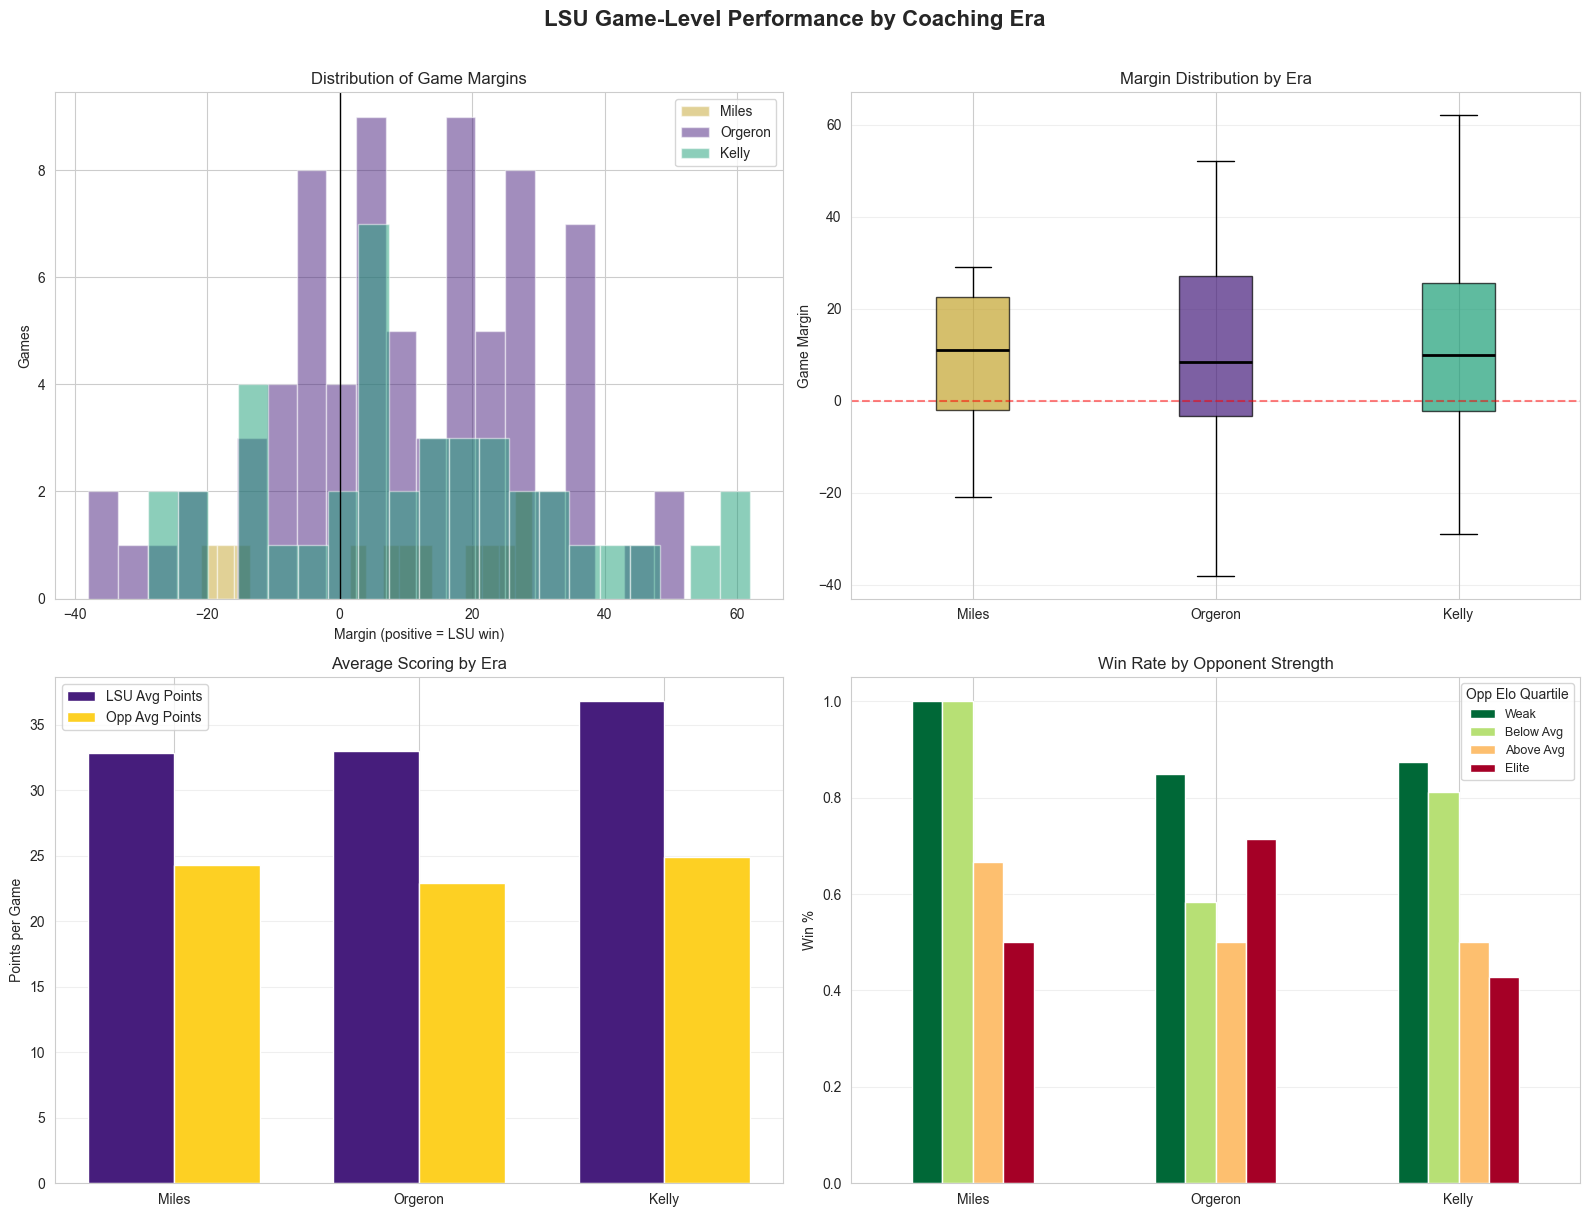

Saved: lsu_game_distributions.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("LSU Game-Level Performance by Coaching Era", fontsize=16, fontweight="bold", y=1.01)

# Filter to completed games
gd = games_df[games_df["season"] <= 2024].copy()

# Panel 1: Margin distribution by era
ax = axes[0, 0]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = gd["era"] == era
    ax.hist(gd[mask]["margin"], bins=20, alpha=0.5, color=ERA_COLORS[era], label=era, edgecolor="white")
ax.axvline(x=0, color="black", linestyle="-", linewidth=1)
ax.set_title("Distribution of Game Margins")
ax.set_xlabel("Margin (positive = LSU win)")
ax.set_ylabel("Games")
ax.legend()

# Panel 2: Box plot of margins by era
ax = axes[0, 1]
era_order_cat = ["Miles", "Orgeron", "Kelly"]
bp_data = [gd[gd["era"] == era]["margin"].dropna() for era in era_order_cat]
bp = ax.boxplot(bp_data, labels=era_order_cat, patch_artist=True,
               medianprops={"color": "black", "linewidth": 2})
for patch, era in zip(bp["boxes"], era_order_cat):
    patch.set_facecolor(ERA_COLORS[era])
    patch.set_alpha(0.7)
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax.set_title("Margin Distribution by Era")
ax.set_ylabel("Game Margin")
ax.grid(True, alpha=0.3, axis="y")

# Panel 3: Scoring output by era
ax = axes[1, 0]
era_scoring = gd.groupby("era").agg(
    avg_lsu_pts=("lsu_points", "mean"),
    avg_opp_pts=("opp_points", "mean"),
).reindex(era_order_cat)
x = np.arange(len(era_scoring))
w = 0.35
ax.bar(x - w/2, era_scoring["avg_lsu_pts"], w, label="LSU Avg Points", color=LSU_PURPLE)
ax.bar(x + w/2, era_scoring["avg_opp_pts"], w, label="Opp Avg Points", color=LSU_GOLD)
ax.set_xticks(x)
ax.set_xticklabels(era_scoring.index)
ax.set_title("Average Scoring by Era")
ax.set_ylabel("Points per Game")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Panel 4: Win % by opponent Elo quartile
ax = axes[1, 1]
gd["opp_elo_bucket"] = pd.qcut(gd["opp_elo"], q=4, labels=["Weak", "Below Avg", "Above Avg", "Elite"])
elo_era = gd.groupby(["era", "opp_elo_bucket"])["lsu_win"].mean().unstack("opp_elo_bucket")
elo_era = elo_era.reindex(era_order_cat)
elo_era.plot(kind="bar", ax=ax, colormap="RdYlGn_r", edgecolor="white")
ax.set_title("Win Rate by Opponent Strength")
ax.set_ylabel("Win %")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Opp Elo Quartile", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("lsu_game_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_game_distributions.png")

### Interpreting the Output

**Margin Histogram (top-left):** Orgeron's distribution (purple) is the widest — a cluster of blowout wins in the +20 to +40 range (the 2019 games) but also a meaningful number of losses in the -10 to -30 range (the 2020-2021 games). Kelly's distribution (teal) is broad as well, with some notable losses in the -30 to -40 range. Miles's small sample (gold, 12 games) is tightly clustered.

**Box Plots (top-right):** The medians are surprisingly similar (Miles ~13, Orgeron ~8.5, Kelly ~10). But **Kelly has the widest interquartile range and the longest whiskers**, meaning the highest variance in game-to-game outcomes. Orgeron's box is compact in the middle but has outliers on both ends. This is counterintuitive — you'd expect Orgeron to show more variance, but his *game-level* variance is actually driven by the season-to-season swings more than game-to-game unpredictability within a season.

**Average Scoring (bottom-left):** Kelly's teams score the most (36.8 ppg) but also allow the most (24.9 ppg). The Orgeron era scored less on average (33.0) but allowed less too (22.9). This reflects the era composition — Orgeron's averages blend the 2019 offensive juggernaut with the 2020-2021 struggles. Kelly's higher scoring reflects the permanently modernized offense, but the defensive points allowed suggest he hasn't yet solved that side of the ball.

**Win Rate by Opponent Strength (bottom-right):** This is the money chart. All three eras beat weak opponents at high rates (~85-100%). The separation happens against quality opponents:
- **Miles** had a small sample but shows a steep dropoff against "Above Avg" and "Elite" opponents (~67% and ~50%)
- **Orgeron** won ~56% against "Below Avg" teams (lower than expected, dragged down by 2020-2021) but won ~75% against elite opponents — that's the 2019 championship run inflating the top end
- **Kelly** shows a consistent decline: ~85% vs weak, ~80% vs below avg, ~50% vs above avg, ~43% vs elite. The pattern is clear — he handles the schedule's easy half well but struggles in top-tier matchups

## 9. Statistical Significance: Are the Eras Really Different?

Eyeballing charts is one thing, but are these differences statistically significant? Let's run some tests. With small samples (1 season for Miles, 6 for Orgeron, 3 for Kelly at season level), we should be humble about what we can conclude — but the game-level data gives us more power.

### What This Code Does

Runs formal statistical significance tests on game-level margins across eras:

1. **Kruskal-Wallis test** — the non-parametric equivalent of ANOVA. Tests whether the three era distributions are drawn from the same population. Non-parametric is appropriate here because game margins aren't normally distributed.
2. **Pairwise Mann-Whitney U tests** — tests each era pair individually to identify which specific comparisons are significant.
3. **Descriptive statistics** — sample sizes, win percentages, mean/median margins, standard deviations, and scoring averages by era.

In [12]:
gd_complete = games_df[games_df["season"] <= 2024].copy()

print("=" * 60)
print("STATISTICAL TESTS: ERA COMPARISONS")
print("=" * 60)

# Game counts by era
print("\n--- Sample Sizes ---")
print(gd_complete.groupby("era").size().reindex(["Miles", "Orgeron", "Kelly"]))

# Kruskal-Wallis test (non-parametric ANOVA) on game margins
groups = [gd_complete[gd_complete["era"] == era]["margin"].dropna() for era in ["Miles", "Orgeron", "Kelly"]]
stat, p = sp_stats.kruskal(*groups)
print(f"\n--- Kruskal-Wallis Test on Game Margins ---")
print(f"H-statistic: {stat:.3f}, p-value: {p:.4f}")
print(f"{'Significant' if p < 0.05 else 'Not significant'} difference in margin distributions (α=0.05)")

# Pairwise Mann-Whitney U tests
print(f"\n--- Pairwise Mann-Whitney U Tests (Margins) ---")
eras = ["Miles", "Orgeron", "Kelly"]
for i in range(len(eras)):
    for j in range(i+1, len(eras)):
        g1 = gd_complete[gd_complete["era"] == eras[i]]["margin"].dropna()
        g2 = gd_complete[gd_complete["era"] == eras[j]]["margin"].dropna()
        stat, p = sp_stats.mannwhitneyu(g1, g2, alternative="two-sided")
        print(f"  {eras[i]} vs {eras[j]}: U={stat:.0f}, p={p:.4f} {'*' if p < 0.05 else ''}")

# Summary stats by era
print(f"\n--- Descriptive Stats by Era ---")
era_stats = gd_complete.groupby("era").agg(
    games=("margin", "count"),
    win_pct=("lsu_win", "mean"),
    avg_margin=("margin", "mean"),
    median_margin=("margin", "median"),
    std_margin=("margin", "std"),
    avg_lsu_pts=("lsu_points", "mean"),
    avg_opp_pts=("opp_points", "mean"),
    avg_total=("total_points", "mean"),
).reindex(["Miles", "Orgeron", "Kelly"])
era_stats

STATISTICAL TESTS: ERA COMPARISONS

--- Sample Sizes ---
era
Miles      12
Orgeron    76
Kelly      40
dtype: int64

--- Kruskal-Wallis Test on Game Margins ---
H-statistic: 0.051, p-value: 0.9749
Not significant difference in margin distributions (α=0.05)

--- Pairwise Mann-Whitney U Tests (Margins) ---
  Miles vs Orgeron: U=442, p=0.8696 
  Miles vs Kelly: U=230, p=0.8280 
  Orgeron vs Kelly: U=1502, p=0.9213 

--- Descriptive Stats by Era ---


,games,win_pct,avg_margin,median_margin,std_margin,avg_lsu_pts,avg_opp_pts,avg_total
era,,,,,,,,
Miles,12,0.75,8.58,11.00,17.75,32.83,24.25,57.08
Orgeron,76,0.70,10.07,8.50,19.74,32.97,22.91,55.88
Kelly,40,0.72,11.90,10.00,23.27,36.77,24.88,61.65


### Interpreting the Output

**The main result: none of the differences are statistically significant.**

The Kruskal-Wallis test returns H=0.051 with p=0.975 — about as far from significance as you can get. The pairwise Mann-Whitney tests tell the same story: Miles vs. Orgeron (p=0.87), Miles vs. Kelly (p=0.83), Orgeron vs. Kelly (p=0.92). None are remotely close to the α=0.05 threshold.

**Why?** Two reasons:

1. **Small samples** — Miles has only 12 games, which gives almost no statistical power to detect anything. Even Orgeron (76 games) vs. Kelly (40 games) is modest for detecting moderate effect sizes in a high-variance sport.
2. **The averages really are similar** — avg margins of 8.6 (Miles), 10.1 (Orgeron), and 11.9 (Kelly) are within a single score of each other. The *shape* of the distributions and the *consistency* differ (standard deviations of 17.8, 19.7, and 23.3), but the central tendencies are close.

**This is actually an important finding.** The coaching eras differ dramatically in *how* they win (offense vs. defense, consistency vs. explosiveness, trajectory over time) but not in *how much* they win by on a per-game basis. The differences we see in SP+, PPA, and style are real — but they manifest as changes in *ceiling and floor* rather than *average outcome*. That's why the season-level SP+ analysis (which captures quality of play) tells a richer story than raw game margins.

The descriptive stats confirm this: Kelly's teams score more (36.8 ppg) but allow more (24.9 ppg), yielding similar net margins. Orgeron's higher standard deviation (19.7) reflects the within-era variance between the 2019 peak and 2020-2021 collapse.

## 10. Returning Production & Continuity

One underappreciated factor in coaching transitions: how much production returns from year to year? Coaching changes create roster churn through transfers, scheme-fit departures, and schematic overhauls. Let's see if that shows up in the data.

### What This Code Does

Plots returning production by era across two metrics:

1. **% of PPA returning** — what fraction of the previous season's predicted-points-added production is back on the roster this year
2. **% of Usage returning** — what fraction of the previous season's snap-weighted involvement is back

These measure roster continuity. Higher values mean more experienced rosters; lower values indicate turnover from NFL departures, transfers, or scheme-fit attrition during coaching changes.

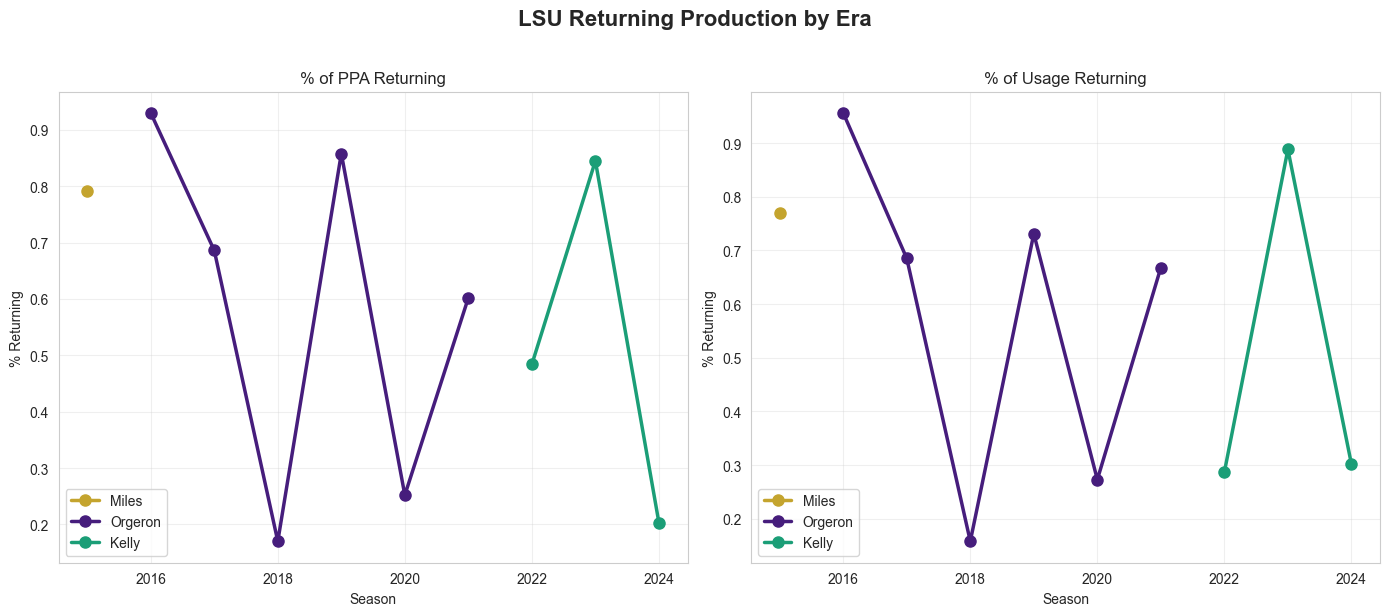

Saved: lsu_returning_production.png


In [13]:
if len(returning_df) > 0:
    ret = returning_df[returning_df["season"] <= 2024].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("LSU Returning Production by Era", fontsize=16, fontweight="bold", y=1.02)

    # Panel 1: % of PPA returning
    ax = axes[0]
    for era in ["Miles", "Orgeron", "Kelly"]:
        mask = ret["era"] == era
        d = ret[mask]
        ax.plot(d["season"], d["percentPPA"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
    ax.set_title("% of PPA Returning")
    ax.set_ylabel("% Returning")
    ax.set_xlabel("Season")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Panel 2: Usage returning
    ax = axes[1]
    for era in ["Miles", "Orgeron", "Kelly"]:
        mask = ret["era"] == era
        d = ret[mask]
        ax.plot(d["season"], d["usage"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
    ax.set_title("% of Usage Returning")
    ax.set_ylabel("% Returning")
    ax.set_xlabel("Season")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("lsu_returning_production.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: lsu_returning_production.png")
else:
    print("No returning production data available.")

### Interpreting the Output

The returning production charts show a striking cyclical pattern:

- **2016 returning production was very high (~93% PPA, ~93% usage)** — this is what returned to the 2016 roster from the 2015 season. High continuity despite the coaching change, because the transition happened mid-season and most players stayed.
- **2018 hit rock bottom (~18% PPA, ~17% usage)** — this was the post-2017 exodus. After a mediocre 9-4 season, a wave of talent left for the NFL Draft and transfers. Orgeron was essentially starting over.
- **2019 bounced back to ~86% PPA** — the 2018 underclass came back, Joe Burrow returned for his senior year, and the roster was loaded with experienced talent. That returning production was a major ingredient in the championship run.
- **2020 returning production cratered (~25% PPA, ~27% usage)** — the championship roster hemorrhaged talent to the NFL. 14 players were drafted, including Burrow, Joe Brady left for the NFL, and the defense lost multiple starters. This is the single biggest year-over-year roster quality collapse in the dataset.
- **Kelly's 2022 (first year) shows ~49% PPA returning** — moderate, reflecting the coaching transition roster churn. His 2023 spiked to ~84% (the Jayden Daniels core came back), then dropped to ~20% in 2024 (the post-Daniels exodus).

**The pattern is clear: elite seasons are typically followed by massive talent departures, which create the "hangover" effect that drives coaching era volatility.** This isn't unique to LSU — it's the structural challenge of college football's annual roster turnover — but it's amplified at programs that produce NFL talent at LSU's rate.

## 11. Composite Era Scorecard

Let's build a final composite view — a radar chart showing each era's strengths and weaknesses across multiple dimensions. This is the performance attribution for each coaching tenure.

### What This Code Does

Builds a composite radar chart comparing the three coaching eras across 7 normalized dimensions:

1. **Win %** — raw winning percentage
2. **Off PPA** — average offensive predicted points added per play
3. **Off Success** — average offensive success rate
4. **Explosiveness** — average explosiveness on successful plays
5. **Def PPA** — defensive PPA allowed (inverted, so higher = better defense)
6. **Def Havoc** — defensive havoc rate
7. **Recruiting** — average recruiting class rank (inverted, so higher = better recruiting)

Each metric is min-max normalized to a 0–1 scale within this dataset, so the chart shows relative strengths across eras rather than absolute values. Defensive metrics are inverted so that "better" always means farther from center.

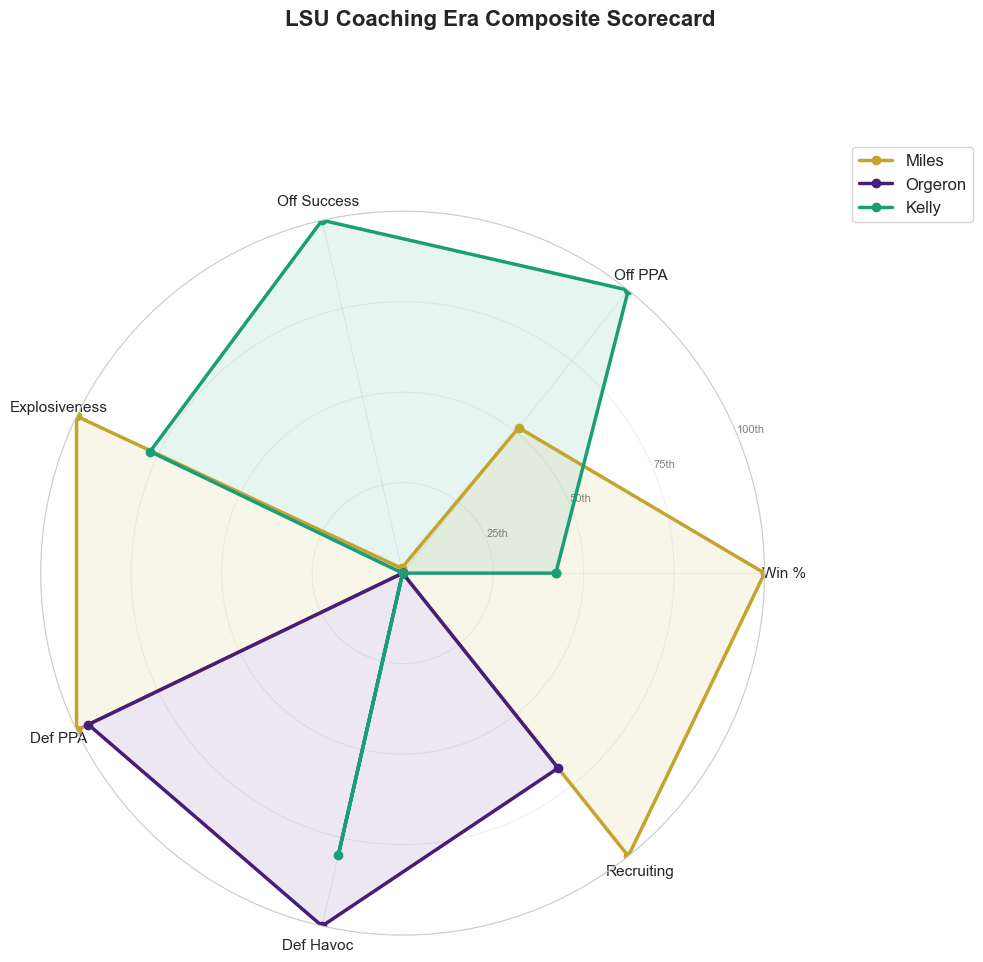

Saved: lsu_era_scorecard.png


In [14]:
# Build normalized scores (0-1 scale, higher = better) for each era
# We use era-level averages from the completed seasons

adv_era = adv_complete.groupby("era").agg(
    off_ppa=("off_ppa", "mean"),
    off_success=("off_success_rate", "mean"),
    off_explosive=("off_explosiveness", "mean"),
    def_ppa=("def_ppa", "mean"),
    def_success=("def_success_rate", "mean"),
    def_havoc=("def_havoc_total", "mean"),
).reindex(["Miles", "Orgeron", "Kelly"])

# For the scorecard, normalize each metric to 0-1 within the dataset
# For defensive metrics, invert so higher = better
def normalize(series, invert=False):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    normed = (series - mn) / (mx - mn)
    return 1 - normed if invert else normed

scores = pd.DataFrame(index=["Miles", "Orgeron", "Kelly"])
scores["Win %"] = era_summary.set_index("era")["win_pct"].reindex(["Miles", "Orgeron", "Kelly"]).pipe(normalize)
scores["Off PPA"] = normalize(adv_era["off_ppa"])
scores["Off Success"] = normalize(adv_era["off_success"])
scores["Explosiveness"] = normalize(adv_era["off_explosive"])
scores["Def PPA"] = normalize(adv_era["def_ppa"], invert=True)
scores["Def Havoc"] = normalize(adv_era["def_havoc"])
scores["Recruiting"] = normalize(
    era_summary.set_index("era")["avg_recruit_rank"].reindex(["Miles", "Orgeron", "Kelly"]),
    invert=True  # Lower rank = better
)

# Radar chart
categories = list(scores.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.suptitle("LSU Coaching Era Composite Scorecard", fontsize=16, fontweight="bold", y=1.02)

for era in ["Miles", "Orgeron", "Kelly"]:
    values = scores.loc[era].tolist()
    values += values[:1]  # close the polygon
    ax.plot(angles, values, "o-", linewidth=2.5, markersize=6, label=era, color=ERA_COLORS[era])
    ax.fill(angles, values, alpha=0.1, color=ERA_COLORS[era])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25th", "50th", "75th", "100th"], fontsize=8, color="gray")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lsu_era_scorecard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_era_scorecard.png")

### Interpreting the Output

The radar chart makes the era identities immediately visible through their shapes:

**Miles (gold):** A polygon tilted toward the right and bottom — strong on Win %, Explosiveness, Def PPA, and Recruiting, but weaker on Off PPA and Off Success. This is the classic LSU identity under Miles: elite defense, strong recruiting, occasional explosive plays, but a conservative offense that didn't generate points efficiently. His shape is the most balanced of the three, without extreme peaks or valleys.

**Orgeron (purple):** The smallest overall polygon, pulled toward Def Havoc and Recruiting but collapsed on almost everything else. This is surprising until you remember what's happening: **his era averages are dragged down by 2020-2021.** The 2019 peak is masked by the average. His Off PPA and Off Success appear low because two terrible offensive seasons outweigh one historic one. His Def PPA is low because the 2020-2021 defensive collapse outweighs the 2016-2018 dominance. The average hides the volatility — he was either the best or the worst.

**Kelly (teal):** The largest overall polygon, leading on Off PPA, Off Success, and Explosiveness. This reflects the modern, pass-first offensive identity that Kelly brought — efficient, high success rate, and explosive. But note the weakness on Def PPA, Def Havoc, and Recruiting — the defensive metrics lag both other eras, and his recruiting rank is the lowest. Kelly's shape says "modern, offense-first program that hasn't solved the defensive side yet."

**The key insight:** If you could combine Miles's defense and recruiting with Kelly's offense, you'd have a championship-caliber program. That's essentially what Orgeron achieved for one magical season in 2019 — and why that season was such an outlier.

## Summary & Key Findings

### The Three Eras at a Glance

| Dimension | Miles (2015-16) | Orgeron (2016-21) | Kelly (2022-24) |
|-----------|----------------|-------------------|-----------------|
| **Identity** | Defense-first, run-heavy | Offense-first, volatile | Balanced, steady |
| **SP+ Trajectory** | Stable, mid-20s | Parabolic (peak 33.1 → trough ~4) | Rise-and-plateau (16-19) |
| **Best Asset** | Defensive consistency | Offensive ceiling (2019) | Consistency & floor |
| **Biggest Weakness** | Offensive ceiling | Sustainability & defense | Lack of elite peak |
| **Coaching Alpha** | Slight positive (defense) | Massive positive (2019), massive negative (2020-21) | Neutral — gets expected value |
| **Talent Utilization** | Efficient | Feast-or-famine | Market rate |

### Key Insights

1. **Orgeron's variance is the defining feature** — his best season is the best in this dataset by a mile, but his worst seasons are the worst. In fund management terms, he had an incredible year but couldn't maintain risk discipline.

2. **The modernization of LSU's offense is real and permanent** — the pass rate shift and passing PPA improvements survived the coaching change from Orgeron to Kelly. This is a structural change, not a cyclical one.

3. **Defense is the variable that separates good LSU teams from elite ones** — with stable top-5 recruiting, the offense always has talent. The defensive coordinator and scheme is where the margin of victory is won or lost.

4. **Kelly is a floor-raiser, not a ceiling-raiser (so far)** — he stabilized the program quickly after the Orgeron collapse but hasn't yet produced an elite season. Whether that's his ceiling or just a matter of time is the open question.

5. **Ties back to the betting analysis** — the betting market was slowest to adjust during the Orgeron peak (2019 ATS: 10-3) and the Orgeron collapse (market kept setting LSU as favorites). The market efficiently prices Kelly-era LSU because there's less regime change to lag.

### Connection to Future Projects

- **Project 3 (Opponent-Adjusted Metrics)** will let us normalize these comparisons for schedule strength
- **Project 4 (Recruiting vs. Performance)** will formalize the talent utilization analysis with regression models
- **Project 5 (Win Probability Model)** will use the era-specific features identified here as predictors